# 01 — Data Loading and Validation

This notebook is the first of three notebooks in the pairs trading research pipeline. Its scope is limited to data loading, data validation, diagnostics inspection, and basic visualization of the loaded price and volume matrices.

The notebook calls the project’s Python modules rather than duplicating logic inside notebook cells. Specifically, it uses the data loading and validation functions defined in `src/` to fetch historical price and volume data, validate the resulting price and volume matrices, inspect diagnostics, save processed data for downstream notebooks, and plot normalized prices.

This notebook loads adjusted close and adjusted volume data from Tiingo.
The adjusted close matrix is validated by the price validator, and the adjusted
volume matrix is validated by the volume validator. A dollar-volume matrix is
created as adjusted close multiplied by adjusted volume, which will be used for
liquidity-aware pair selection in Notebook 02.

The full project notebook flow is:

1. `01_data_loading_validation.ipynb` — load and validate market data.
2. `02_spread_modeling.ipynb` — compute log prices, hedge model, spread, and z-score.
3. `03_backtest_report.ipynb` — run backtest logic and summarize performance metrics.

This notebook has 8 sections as follows:

 1. Project Setup and Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import json

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import fetch_tiingo_price_matrix
from src.config_loader import (
    load_run_config,
    load_universe_config
)

print(PROJECT_ROOT)

c:\Users\Aditi\Aditi_Workspaces\VSCode\QuantProjects\pairs-trading-ai-tech


2. Load Environment variables

In [2]:
load_dotenv(PROJECT_ROOT / ".env")
api_key = os.getenv("TIINGO_API_KEY")

3. Define tickers and date range. AAPL and MSFT are used as an initial large-cap technology pair for pipeline demonstration. Pair choice is illustrative in v1; later versions can add systematic pair selection using correlation, cointegration, sector grouping, and stability checks.

In [3]:
run_json_file_path = PROJECT_ROOT/"config/run_config.json"
v1_universe_file_path = PROJECT_ROOT/"config/v1_universe.json"

config = load_run_config(run_json_file_path)
v1_univ = load_universe_config(v1_universe_file_path)
    
tickers = v1_univ["tickers"]
start_date = config["date_range"]["start_date"]
end_date = config["date_range"]["end_date"]
price_field = config["data_loader"]["price_field"]
volume_field = config["data_loader"]["volume_field"]
validate = config["data_loader"]["validate"]

print("Tickers:",tickers)
print("Start Date:",start_date)
print("End Date:",end_date)
print("Price Field:",price_field)
print("Volume_field:",volume_field)
print("Validate:",validate)

Tickers: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMZN', 'ADBE', 'CRM', 'ORCL', 'INTC']
Start Date: 2020-01-01
End Date: 2024-12-31
Price Field: adjClose
Volume_field: adjVolume
Validate: True


4. Fetch prices using fetch_tiingo_price_matrix()

In [4]:
price_matrix, volume_matrix, loader_diagnostics = fetch_tiingo_price_matrix(tickers,start_date,end_date,api_key=api_key,price_field=price_field,volume_field=volume_field,validate=validate)

5. Inspect price matrix and volume matrix

In [5]:
price_matrix.head()

,AAPL,MSFT,NVDA,GOOGL,META,AMZN,ADBE,CRM,ORCL,INTC
date,,,,,,,,,,
2020-01-02 00:00:00+00:00,72.339604,151.817457,5.964042,67.829032,207.978449,94.9005,334.43,164.103719,49.159296,53.666888
2020-01-03 00:00:00+00:00,71.636319,149.927064,5.868582,67.474197,206.877982,93.7485,331.81,163.297892,48.986167,53.014135
2020-01-06 00:00:00+00:00,72.207136,150.314595,5.893193,69.272657,210.774232,95.1440,333.71,170.452063,49.241304,52.864178
2020-01-07 00:00:00+00:00,71.867536,148.944060,5.964539,69.138850,211.230281,95.3430,333.39,172.957989,49.350648,51.982079
2020-01-08 00:00:00+00:00,73.023621,151.316503,5.975726,69.630961,213.371731,94.5985,337.87,174.265001,49.542000,52.017363


In [6]:
price_matrix.shape

(1258, 10)

In [7]:
volume_matrix.head()

,AAPL,MSFT,NVDA,GOOGL,META,AMZN,ADBE,CRM,ORCL,INTC
date,,,,,,,,,,
2020-01-02 00:00:00+00:00,135647456,22634546,237678760,27285300,12090707,80718200,1990496,5188565,13899603,17713404
2020-01-03 00:00:00+00:00,146535512,21121681,205772320,23412580,11197416,75332080,1579371,3205298,11026715,15298577
2020-01-06 00:00:00+00:00,118578576,20826702,262912480,46786860,17073861,81313960,1875122,8835057,10975900,17759137
2020-01-07 00:00:00+00:00,111510620,21881740,319205760,34529120,15111857,82680200,2507261,8289799,12029590,21960524
2020-01-08 00:00:00+00:00,132363784,27762026,277240680,35325480,13492703,70239320,2248531,7224992,11856737,23138274


In [8]:
volume_matrix.shape

(1258, 10)

In [9]:
print(price_matrix.index.equals(volume_matrix.index))
print(price_matrix.columns.equals(volume_matrix.columns))

True
True


In [10]:
dollar_volume_matrix = price_matrix * volume_matrix
print(dollar_volume_matrix.head())
print(dollar_volume_matrix.shape)

                                   AAPL          MSFT          NVDA  \
date                                                                  
2020-01-02 00:00:00+00:00  9.812683e+09  3.436319e+09  1.417526e+09   
2020-01-03 00:00:00+00:00  1.049726e+10  3.166712e+09  1.207592e+09   
2020-01-06 00:00:00+00:00  8.562219e+09  3.130557e+09  1.549394e+09   
2020-01-07 00:00:00+00:00  8.013994e+09  3.259155e+09  1.903915e+09   
2020-01-08 00:00:00+00:00  9.665683e+09  4.200853e+09  1.656714e+09   

                                  GOOGL          META          AMZN  \
date                                                                  
2020-01-02 00:00:00+00:00  1.850735e+09  2.514606e+09  7.660198e+09   
2020-01-03 00:00:00+00:00  1.579745e+09  2.316499e+09  7.062270e+09   
2020-01-06 00:00:00+00:00  3.241050e+09  3.598730e+09  7.736535e+09   
2020-01-07 00:00:00+00:00  2.387304e+09  3.192082e+09  7.882978e+09   
2020-01-08 00:00:00+00:00  2.459747e+09  2.878961e+09  6.644534e+09   

    

6. Inspect loader diagnostics

In [11]:
print(loader_diagnostics.keys())

dict_keys(['data_source', 'tickers_requested', 'start_date', 'end_date', 'price_field', 'volume_field', 'data_loader_checks_passed', 'ticker_loader_diagnostics', 'price_matrix_summary', 'volume_matrix_summary', 'validation_was_run', 'price_validation_diagnostics', 'volume_validation_diagnostics'])


In [12]:
print("Data Loader Checks:-",loader_diagnostics['data_loader_checks_passed'])
print("Price Matrix Statistics:-",loader_diagnostics['price_matrix_summary'])
print("Price Matrix Validation:-",loader_diagnostics['price_validation_diagnostics'])
print("Volume Matrix Statistics:-",loader_diagnostics['volume_matrix_summary'])
print("Volume Matrix Validation:-",loader_diagnostics['volume_validation_diagnostics'])

Data Loader Checks:- ['API key check passed.', 'Tickers list check passed.', 'Tickers type check passed.', 'Each ticker is a string check passed.', 'Each ticker is not an empty string check passed.', 'Start date and end date presence check passed.', 'Start date and end date are convertible.', 'Start date is less than end date.', 'Validate parameter type check passed.', 'Price matrix created.', 'Price matrix sorted by date.', 'Volume matrix created.', 'Volume matrix sorted by date.', 'Price matrix validation applied.', 'Volume matrix validation applied.']
Price Matrix Statistics:- {'num_observations': 1258, 'num_assets': 10, 'start_date': Timestamp('2020-01-02 00:00:00+0000', tz='UTC'), 'end_date': Timestamp('2024-12-31 00:00:00+0000', tz='UTC'), 'asset_list': ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMZN', 'ADBE', 'CRM', 'ORCL', 'INTC']}
Price Matrix Validation:- {'is_valid': True, 'num_observations': 1258, 'num_assets': 10, 'start_date': Timestamp('2020-01-02 00:00:00+0000', tz='UTC

In [13]:
print("Ticker Diagnostics:-",pd.DataFrame(loader_diagnostics['ticker_loader_diagnostics']))

Ticker Diagnostics:-   ticker  tiingo_request_successful  data_not_empty  date_column_present  \
0   AAPL                       True            True                 True   
1   MSFT                       True            True                 True   
2   NVDA                       True            True                 True   
3  GOOGL                       True            True                 True   
4   META                       True            True                 True   
5   AMZN                       True            True                 True   
6   ADBE                       True            True                 True   
7    CRM                       True            True                 True   
8   ORCL                       True            True                 True   
9   INTC                       True            True                 True   

   price_field_present  volume_field_present  date_column_converted  \
0                 True                  True                   True   


7. Save price_matrix to data/processed

In [14]:
#Define filepath
price_file_path = PROJECT_ROOT/f"data/processed/price_matrix_v1_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"
volume_file_path = PROJECT_ROOT/f"data/processed/volume_matrix_v1_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"
dollar_matrix_file_path = PROJECT_ROOT/f"data/processed/dollar_volume_matrix_v1_{pd.Timestamp(start_date).strftime('%Y')}_{pd.Timestamp(end_date).strftime('%Y')}.csv"

#Ensure that the directory exists
os.makedirs(os.path.dirname(price_file_path), exist_ok=True)
os.makedirs(os.path.dirname(volume_file_path), exist_ok=True)
os.makedirs(os.path.dirname(dollar_matrix_file_path), exist_ok=True)

#Save the DataFrame
price_matrix.to_csv(price_file_path, index=True, encoding='utf-8')
volume_matrix.to_csv(volume_file_path, index=True, encoding='utf-8')
dollar_volume_matrix.to_csv(dollar_matrix_file_path, index=True, encoding='utf-8')

8. Plot normalized prices.

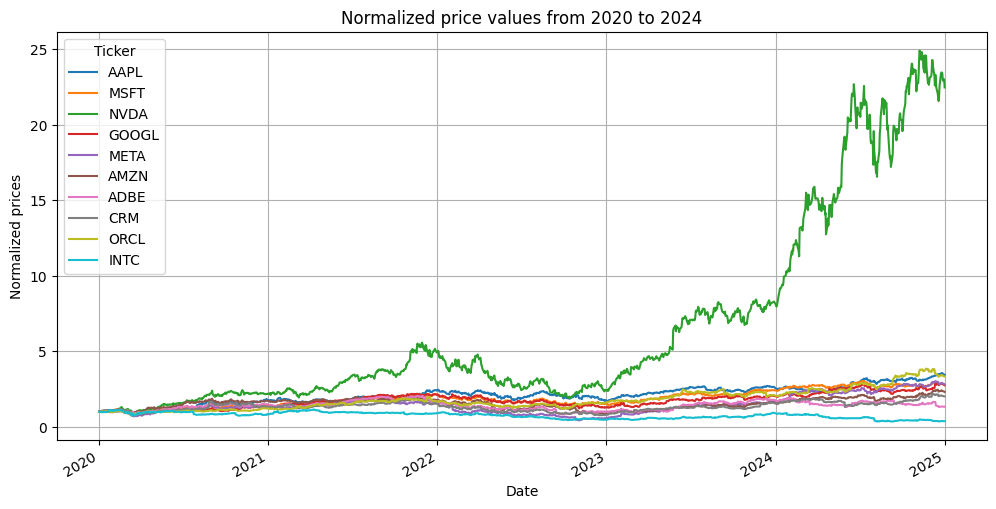

In [15]:
normalized_prices = price_matrix/price_matrix.iloc[0]
normalized_prices.plot(figsize=(12,6))
plt.title('Normalized price values from 2020 to 2024')
plt.xlabel('Date')
plt.ylabel('Normalized prices')
plt.legend(title="Ticker")
plt.grid(True)
plt.show()


The notebook is intentionally kept thin: core logic is implemented in `src/data_loader.py` and `src/data_validator.py`, while this notebook demonstrates usage and inspects outputs.